# W02 · Gymnasium API 与自定义环境

> 阶段一第 2 周。本周我们站在「环境作者」的视角：读懂 Gymnasium 的接口契约，
> 解剖并验证一个自定义环境 `DroneHoverEnv`，最后用 SB3 在上面训练第一个策略。

## 学习目标

1. 熟练掌握 Gymnasium 的核心 API：`reset()` / `step()` 的返回值契约、`terminated` vs `truncated`、常用 `spaces`；
2. 说清一个规范自定义环境必须实现的要素（`observation_space` / `action_space` / `reset` / `step` / 随机种子）；
3. 用 `stable_baselines3.common.env_checker.check_env` 自动体检自定义环境；
4. 用 `gym.register` 注册环境，并用 SB3 PPO 训练 + 画学习曲线；
5. 理解奖励塑形（reward shaping）对训练行为的影响。

**先修要求**：W01（MDP 五元组与回报的定义）。预计用时 2–3 小时。

## 1. Gymnasium API：环境界的「USB 接口标准」

Gymnasium（OpenAI Gym 的社区继任者）只规定一件事：**环境长什么样不重要，接口必须统一**。
就像 USB 标准让任何键盘都能插任何电脑，Gymnasium 让任何算法都能接任何环境。

核心契约（Gym API 五步循环）：

```python
obs, info = env.reset(seed=42)          # 1. 重置，拿初始观测
obs, reward, terminated, truncated, info = env.step(action)  # 2. 推进一步
```

- `obs`：观测（属于 `observation_space`）；
- `reward`：标量奖励；
- **`terminated`**：任务层面的结束（到达终点/坠毁/立杆倒下）——Bellman 意义上 $V(\text{terminal}) = 0$；
- **`truncated`**：外部截断（到达时间上限）——回合结束但状态本身**有价值**，bootstrapping 时不能当 0 处理。
  这个区分对价值学习至关重要，写自定义环境时最容易搞错。

常用 `spaces`（空间对象，定义取值范围 + 提供 `sample()` 随机采样）：

| Space | 含义 | 机器人对应 |
|---|---|---|
| `Discrete(n)` | $\{0,1,\dots,n-1\}$ | 离散指令（抓取/松开） |
| `Box(low, high, shape)` | 连续向量 | 关节力矩、位姿 |
| `MultiDiscrete` / `Dict` | 组合空间 | 多模态观测 |

In [1]:
import gymnasium as gym
import numpy as np

env = gym.make("CartPole-v1")
print("observation_space:", env.observation_space)
print("action_space     :", env.action_space)

# 随机策略交互：统计回合长度
lengths = []
for ep in range(5):
    obs, _ = env.reset(seed=ep)
    terminated = truncated = False
    steps = 0
    while not (terminated or truncated):
        obs, r, terminated, truncated, _ = env.step(env.action_space.sample())
        steps += 1
    lengths.append(steps)
env.close()
print(f"随机策略 5 个回合的长度: {lengths}")
print("→ CartPole-v1 的时间上限是 500 步（truncated），杆倒下是 terminated")

observation_space: Box([-4.8000002e+00 -3.4028235e+38 -4.1887903e-01 -3.4028235e+38], [4.8000002e+00 3.4028235e+38 4.1887903e-01 3.4028235e+38], (4,), float32)
action_space     : Discrete(2)
随机策略 5 个回合的长度: [14, 35, 15, 17, 17]
→ CartPole-v1 的时间上限是 500 步（truncated），杆倒下是 terminated


## 2. 解剖一个自定义环境：DroneHoverEnv

本项目在 `src/robot_rl_learn/phase1_sb3/envs.py` 中实现了一个教学环境**一维无人机定高悬停**：

- **物理模型**：质点垂直运动，$\dot{v} = a$，$a \in [-g, g]$ 由归一化推力映射而来；
- **观测**：$[h - h_{target},\; v]$（高度误差 + 垂直速度），`Box` 连续空间；
- **动作**：$u \in [-1, 1]$ 归一化推力；
- **奖励**（稠密、二次型惩罚，控制理论里的 LQR 风格）：
  $$r = -\big[(h-h_{target})^2 + 0.1\, v^2 + 0.01\, u^2\big]$$
  三项分别惩罚：高度误差（主要目标）、速度（抑制振荡）、推力（节能）；
- **终止**：$|h - h_{target}| > 3$ m（飞出安全范围，`terminated`）；满 500 步 `truncated`。

一个规范自定义环境的**清单**：
1. 继承 `gym.Env`；2. 在 `__init__` 定义两个 space；3. `reset` 返回 `(obs, info)` 并支持 `seed=`；
4. `step` 返回五元组；5. 观测的 dtype/范围与 space 声明严格一致。
下面把它跑出来看看：

In [2]:
from robot_rl_learn.phase1_sb3.envs import DroneHoverEnv

env = DroneHoverEnv(target_height=1.0)
obs, info = env.reset(seed=0)
print("初始观测 [高度误差, 垂直速度]:", obs)

# 用「比例控制器」当手动策略：误差为负（低于目标）就加大推力
for t in range(10):
    action = np.array([np.clip(-2.0 * obs[0] - 0.5 * obs[1], -1, 1)])
    obs, r, terminated, truncated, _ = env.step(action)
    print(f"t={t:2d} 高度误差={obs[0]:+.3f}  速度={obs[1]:+.3f}  reward={r:.4f}")
print("→ 简单的 PD 控制就能让误差收敛——这个环境的动力学很温和，适合教学")

初始观测 [高度误差, 垂直速度]: [ 0.27392337 -0.23021328]
t= 0 高度误差=+0.268  速度=-0.315  reward=-0.0834
t= 1 高度误差=+0.260  速度=-0.389  reward=-0.0841
t= 2 高度误差=+0.251  速度=-0.453  reward=-0.0845
t= 3 高度误差=+0.241  速度=-0.507  reward=-0.0844
t= 4 高度误差=+0.230  速度=-0.552  reward=-0.0837
t= 5 高度误差=+0.218  速度=-0.588  reward=-0.0823
t= 6 高度误差=+0.206  速度=-0.615  reward=-0.0803
t= 7 高度误差=+0.193  速度=-0.636  reward=-0.0777
t= 8 高度误差=+0.180  速度=-0.649  reward=-0.0745
t= 9 高度误差=+0.167  速度=-0.656  reward=-0.0708
→ 简单的 PD 控制就能让误差收敛——这个环境的动力学很温和，适合教学


## 3. 用 `check_env` 给环境做体检

手写环境最常见的 bug：obs 的 dtype 不对（float64 vs float32）、超出 space 声明范围、
`reset` 没处理 seed、`terminated/truncated` 用错。SB3 提供了自动化检查器
`stable_baselines3.common.env_checker.check_env`，它会：

- 检查 `reset/step` 返回值结构是否符合 Gymnasium 契约；
- 用随机动作反复 `step`，验证观测始终在 `observation_space` 内、类型匹配；
- 检查渲染模式、`__init__` 是否调用了 `super()` 等规范。

**以后每写/每改一个自定义环境，第一件事就是跑 `check_env`。**

> 注：运行时若看到 `render_mode='rgb_array' that is not in the possible render_modes` 的 UserWarning，
> 这是 `check_env` 在主动探测渲染接口——`DroneHoverEnv` 声明了 `render_modes=[]`（不渲染），
> 该警告无害，恰好说明检查器真的在验证元数据契约。

In [3]:
from stable_baselines3.common.env_checker import check_env

check_env(DroneHoverEnv())   # 全部通过则静默返回；有任何不规范会抛出带说明的异常/警告
print("✅ DroneHoverEnv 通过 SB3 环境检查")

✅ DroneHoverEnv 通过 SB3 环境检查


## 4. 注册环境，用 SB3 训练第一个策略

`gym.register` 给环境一个字符串 id，之后就能像 `CartPole-v1` 一样 `gym.make`，
也能直接传给 SB3 的训练辅助函数。

下面用 **PPO**（W05 会深入，本周先当黑箱用）在 DroneHoverEnv 上训练 20,000 步，
并用项目 `plots` 模块画学习曲线。Monitor 日志写到 `runs/`（项目约定）。

In [4]:
import gymnasium as gym
from gymnasium.envs.registration import register

# 注册一次即可；重复执行本 cell 前先注销，避免重注册警告
if "DroneHover-v0" in gym.registry:
    gym.spec("DroneHover-v0")  # 已注册则跳过
else:
    register(id="DroneHover-v0", entry_point="robot_rl_learn.phase1_sb3.envs:DroneHoverEnv")

print(gym.make("DroneHover-v0"))

<OrderEnforcing<PassiveEnvChecker<DroneHoverEnv<DroneHover-v0>>>>


In [5]:
import time
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from robot_rl_learn.common.paths import make_run_dir
from robot_rl_learn.phase1_sb3.train import make_envs, evaluate

run_dir = make_run_dir("w02_drone_hover_ppo")

t0 = time.time()
train_env = make_envs("DroneHover-v0", n_envs=4, seed=0)   # 4 个并行环境采样
model = PPO("MlpPolicy", train_env, seed=0, verbose=0, device="cpu")  # 显式 CPU：MlpPolicy 在 CPU 上更快
model.learn(total_timesteps=20_000)
print(f"训练 20k 步耗时 {time.time() - t0:.1f}s（CPU）")

mean_r, std_r = evaluate(model, "DroneHover-v0", n_episodes=20)
print(f"确定性评估（20 回合）: mean reward = {mean_r:.2f} ± {std_r:.2f}")
print("对照：奖励各项均为非正惩罚，回报越接近 0 说明悬停得越稳")

/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:788: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


训练 20k 步耗时 607.8s（CPU）


/data/wangf/robot_rl_learn/.venv/lib/python3.11/site-packages/gymnasium/envs/registration.py:788: UserWarning: WARN: The environment is being initialised with render_mode='rgb_array' that is not in the possible render_modes ([]).
  logger.warn(


确定性评估（20 回合）: mean reward = -25.21 ± 12.33
对照：奖励各项均为非正惩罚，回报越接近 0 说明悬停得越稳


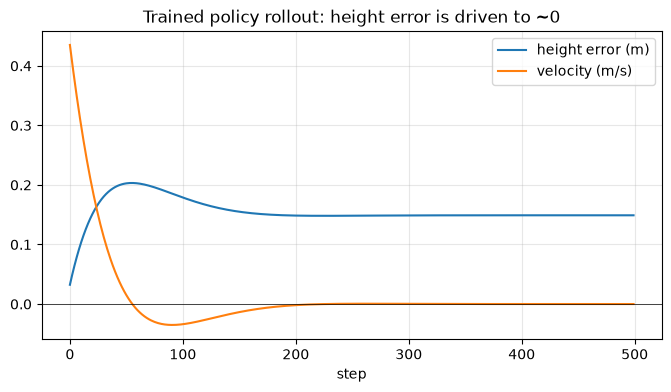

In [6]:
from robot_rl_learn.phase1_sb3.plots import plot_learning_curve
import matplotlib.pyplot as plt

# train.py 的 make_envs 会给环境包 Monitor，但本 cell 用的是手动 learn，没有 Monitor 日志目录；
# 这里改用 model 在训练环境上的 episode 统计不可行，因此直接画「评估回报」太单薄——
# 更规范的做法是用带 Monitor 的训练流程（W07 详解）。本周先用训练前后的定性对比：
env = gym.make("DroneHover-v0")
obs, _ = env.reset(seed=1)
traj = []
terminated = truncated = False
while not (terminated or truncated):
    action, _ = model.predict(obs, deterministic=True)
    obs, r, terminated, truncated, _ = env.step(action)
    traj.append([obs[0], obs[1]])
env.close()

traj = np.array(traj)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(traj[:, 0], label="height error (m)")
ax.plot(traj[:, 1], label="velocity (m/s)")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("step"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Trained policy rollout: height error is driven to ~0")
plt.show()

## 5. 奖励塑形（reward shaping）：你写什么，它学什么

DroneHoverEnv 的奖励是**稠密**的：每一步都告诉智能体离目标多远。
对比**稀疏奖励**（只有到达目标才 +1）：信号太少，随机探索几乎碰不到正反馈，训练极其困难。

但稠密奖励是把双刃剑——智能体会精确地优化你写的式子，而不是你脑子里的意图：

- 若去掉速度惩罚 $0.1v^2$：可能学到「快速冲到目标附近再猛刹」的振荡行为；
- 若去掉推力惩罚 $0.01u^2$：动作可能打满饱和，真机上烧电机；
- 若加「每存活一步 +0.1」：可能学到「赖在安全区内不靠近目标」。

**工程经验**：先用物理直觉写二次型/LQR 风格惩罚，训练后回放轨迹，
发现「钻空子」行为再有针对性地加项——练习 2 会让你亲手体验。

---

## ✏️ 练习

**练习 1（★，10 分钟）——随机策略基线**
写随机策略在 DroneHoverEnv 上跑 100 个回合，统计并打印平均回合长度与平均回报。
**交付物**：打印输出的统计 cell + 一句「随机策略差在哪」的评论。

**练习 2（★★，30 分钟）——改奖励，看行为**
复制 `DroneHoverEnv` 源码为 notebook 中的 `MyDroneEnv`，做一处奖励修改（例如速度惩罚系数 0.1→0.5，
或每步 +0.1 存活奖励），用 `check_env` 验证后重新训练 PPO（20k 步），
画出与原版训练后轨迹的对比图。
**交付物**：对比图 + 3 句话结论（行为发生了什么变化？符合你的预期吗？）。

**练习 3（★，10 分钟）——体会 check_env 的排查能力**
故意在你复制的环境里制造一个 bug（例如 `_get_obs` 返回 `dtype=np.float64`，或观测上限声明为 1.0 但实际能到 5.0），
跑 `check_env`，把报错信息粘到 markdown 里并解释它检查的是哪条契约。
**交付物**：报错文本 + 一行解释。

**练习 4（★★★，40 分钟）——观测噪声下的鲁棒性**
写一个 `gym.ObservationWrapper`，给观测加高斯噪声（$\sigma = 0.02$）。
用第 4 节训好的 `model` 分别在干净/加噪环境上评估 20 回合，做成两行对比表。
**交付物**：对比表 + 两句话分析（这为 M5 的 Sim2Real 观测噪声周埋下伏笔）。

---

<details>
<summary>参考答案（做完再点开）</summary>

**练习 1**：

```python
env = DroneHoverEnv()
lengths, returns = [], []
for ep in range(100):
    obs, _ = env.reset(seed=ep)
    terminated = truncated = False
    G, steps = 0.0, 0
    while not (terminated or truncated):
        obs, r, terminated, truncated, _ = env.step(env.action_space.sample())
        G += r; steps += 1
    lengths.append(steps); returns.append(G)
print(f"平均回合长度 {np.mean(lengths):.1f}，平均回报 {np.mean(returns):.1f}")
```

随机推力毫无反馈控制，高度很快飘出 ±3 m 安全区而 `terminated`，回合短、回报非常低。

**练习 2**：以「+0.1 存活奖励」为例：由于存活奖励与高度误差无关，
智能体可能学到「悬停在安全区边缘、不精确对准目标」也能拿高分——
总回报上升了，但高度误差反而变大。这就是 reward hacking 的温和版：
**指标变好 ≠ 任务做好**。修改后务必先 `check_env(MyDroneEnv())` 再训练。

**练习 3**：例如把 `_get_obs` 的 `dtype=np.float32` 删掉，`check_env` 会报类似
`The observation returned by ... is not within the observation space`（因为 `Box` 声明的是 float32，
astype 检查失败）。它验证的是「观测必须落在声明的空间内（含 dtype）」这条契约。

**练习 4**：

```python
class NoisyObs(gym.ObservationWrapper):
    def __init__(self, env, sigma=0.02):
        super().__init__(env); self.sigma = sigma
    def observation(self, obs):
        return obs + self.env.np_random.normal(0, self.sigma, obs.shape).astype(np.float32)
```

用 `evaluate_policy(model, NoisyObs(gym.make("DroneHover-v0")), ...)` 对比。
通常回报会退化一些；若训练时就注入噪声（domain randomization 的雏形），鲁棒性会显著变好——M5 会系统讲。

</details>

---

## 延伸阅读

- [Gymnasium 官方文档：Basic Usage](https://gymnasium.farama.org/introduction/basic_usage/) 与 [自定义环境教程](https://gymnasium.farama.org/tutorials/gymnasium_basics/environment_creation/)
- [SB3 文档：Custom Environment](https://stable-baselines3.readthedocs.io/en/master/guide/custom_env.html)（含 check_env 用法）
- [Gymnasium Spaces 文档](https://gymnasium.farama.org/api/spaces/)
- Sutton & Barto 第 3.8 节（奖励设计的讨论）与第 17 章（reward shaping 的形式化）
- 经典论文：[Ng, Harada, Russell (1999) Policy invariance under reward transformations](https://people.eecs.berkeley.edu/~russell/papers/icml99-shaping.pdf)——势函数塑形的理论基础。